# 📊 시장 전체 분석 (Market Overview)

**전제:** `01_data_collection.ipynb` 실행 완료 후 실행

분석 내용:
- 코스피/코스닥 지수 추이 (주요 이벤트 포함)
- 연도별 전 종목 수익률 분포
- 5년 누적 수익률 상위/하위 종목
- 시가총액 기준 기업군별 성과 비교
- 주요 대형주 상관관계 히트맵

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import FinanceDataReader as fdr

from src.data_collector import get_stock_list, load_all_close_prices

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
print('준비 완료!')

준비 완료!


In [2]:
# ─────────────────────────────────────────
# 1단계: 전 종목 종가 데이터 로드
# ─────────────────────────────────────────
close_df = load_all_close_prices(min_days=200)
returns = close_df.pct_change().dropna(how='all')

print(f'분석 대상: {close_df.shape[1]:,}개 종목')
print(f'기간: {close_df.index[0].date()} ~ {close_df.index[-1].date()}')

2731개 파일 로드 중...


종가 합치는 중: 100%|█████████████████████████████████████████████████████████████| 2731/2731 [00:08<00:00, 319.61it/s]


완료: 2658개 종목, 1719거래일
분석 대상: 2,658개 종목
기간: 2019-01-02 ~ 2025-12-30


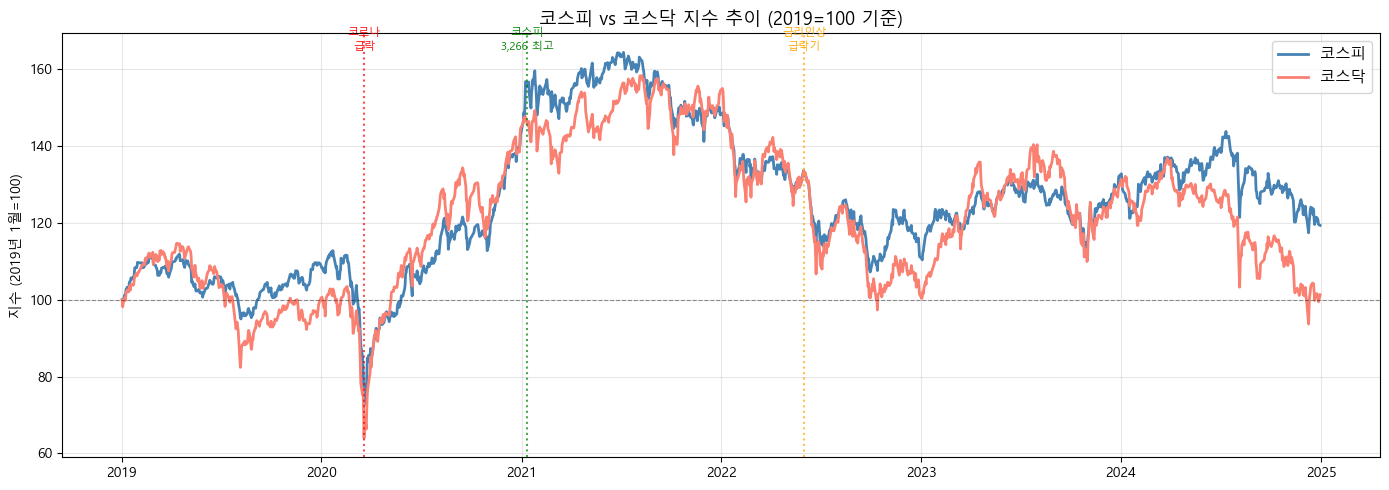

In [3]:
# ─────────────────────────────────────────
# 2단계: 코스피/코스닥 지수 추이
# ─────────────────────────────────────────
kospi = fdr.DataReader('KS11', '2019-01-01', '2024-12-31')['Close']
kosdaq = fdr.DataReader('KQ11', '2019-01-01', '2024-12-31')['Close']

# 2019년 기준 100으로 정규화
kospi_norm = kospi / kospi.iloc[0] * 100
kosdaq_norm = kosdaq / kosdaq.iloc[0] * 100

plt.figure(figsize=(14, 5))
plt.plot(kospi_norm.index, kospi_norm, label='코스피', color='steelblue', linewidth=2)
plt.plot(kosdaq_norm.index, kosdaq_norm, label='코스닥', color='salmon', linewidth=2)

# 주요 이벤트 표시
events = {
    '2020-03-19': ('코로나\n급락', 'red'),
    '2021-01-11': ('코스피\n3,266 최고', 'green'),
    '2022-06-01': ('금리인상\n급락기', 'orange'),
}
for date, (label, color) in events.items():
    plt.axvline(x=pd.Timestamp(date), color=color, linestyle=':', alpha=0.7)
    plt.text(pd.Timestamp(date), 165, label, color=color, fontsize=8, ha='center')

plt.axhline(y=100, color='black', linestyle='--', alpha=0.4, linewidth=0.8)
plt.title('코스피 vs 코스닥 지수 추이 (2019=100 기준)', fontsize=13)
plt.ylabel('지수 (2019년 1월=100)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

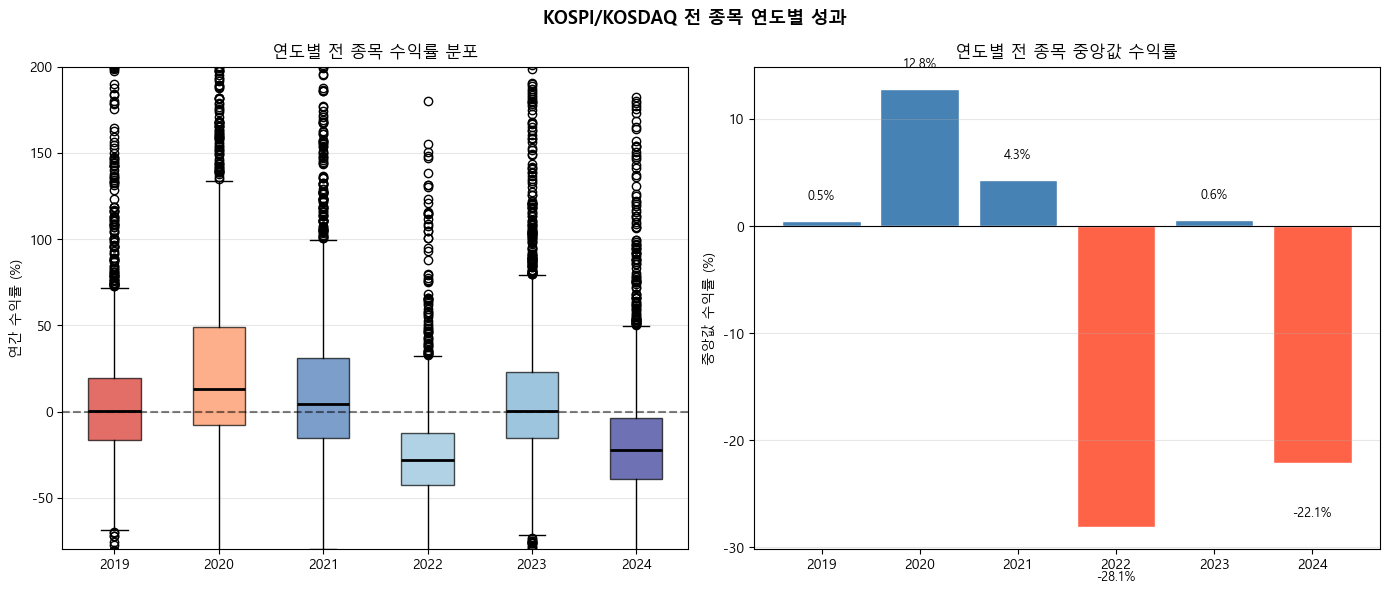

In [4]:
# ─────────────────────────────────────────
# 3단계: 연도별 전 종목 수익률 분포
# ─────────────────────────────────────────
annual_returns = {}
for year in range(2019, 2025):
    year_data = close_df[close_df.index.year == year]
    if len(year_data) > 10:
        ret = (year_data.iloc[-1] / year_data.iloc[0] - 1) * 100
        annual_returns[str(year)] = ret.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 박스플롯
data_for_box = [v.values for v in annual_returns.values()]
bp = axes[0].boxplot(data_for_box, labels=list(annual_returns.keys()),
                     patch_artist=True, medianprops=dict(color='black', linewidth=2))
colors = ['#d73027', '#fc8d59', '#4575b4', '#91bfdb', '#74add1', '#313695']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('연도별 전 종목 수익률 분포')
axes[0].set_ylabel('연간 수익률 (%)')
axes[0].set_ylim(-80, 200)
axes[0].grid(True, alpha=0.3, axis='y')

# 연도별 중앙값
medians = {yr: v.median() for yr, v in annual_returns.items()}
colors_bar = ['tomato' if v < 0 else 'steelblue' for v in medians.values()]
axes[1].bar(medians.keys(), medians.values(), color=colors_bar, edgecolor='white')
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('연도별 전 종목 중앙값 수익률')
axes[1].set_ylabel('중앙값 수익률 (%)')
for i, (yr, v) in enumerate(medians.items()):
    axes[1].text(i, v + (2 if v >= 0 else -5), f'{v:.1f}%', ha='center', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('KOSPI/KOSDAQ 전 종목 연도별 성과', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

캐시에서 로드: 2770개 종목


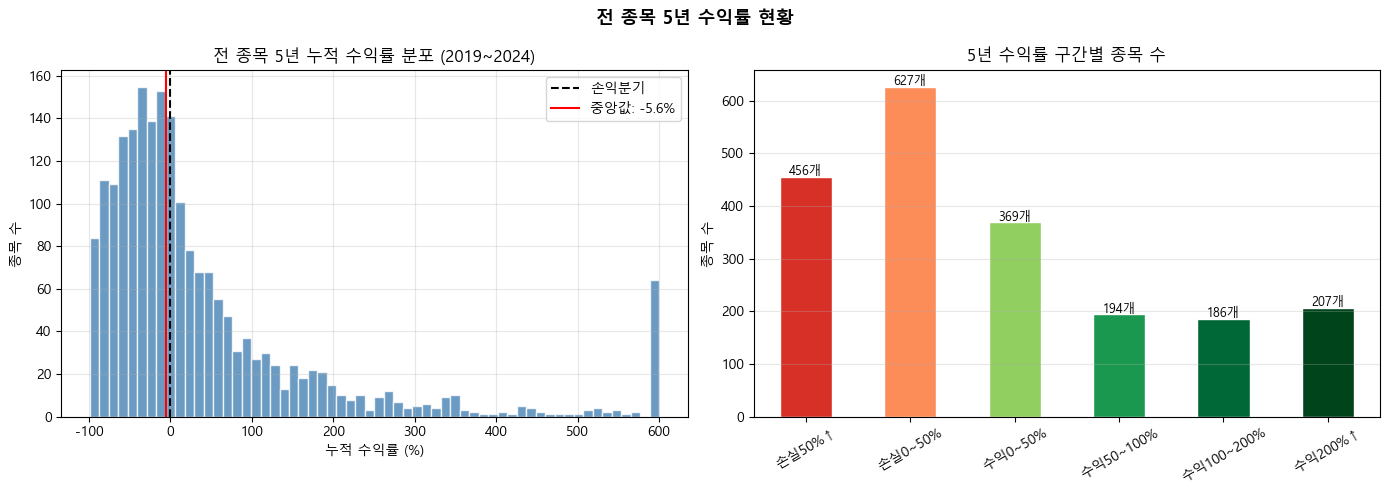

=== 5년 수익률 통계 ===
분석 종목: 2,039개
수익 종목: 956개 (46.9%)
손실 종목: 1,083개 (53.1%)
평균 수익률: 64.1%
중앙값 수익률: -5.6%

=== 5년 수익률 상위 10종목 ===
  101360 에코앤드림       : +5913.7%
  196170 알테오젠        : +5130.4%
  298040 효성중공업       : +4140.5%
  267260 HD현대일렉트릭    : +3976.7%
  042700 한미반도체       : +3292.8%
  012450 한화에어로스페이스   : +2703.6%
  003230 삼양식품        : +2357.1%
  211050 인카금융서비스     : +2281.0%
  086520 에코프로        : +2138.7%
  007660 이수페타시스      : +1908.8%

=== 5년 수익률 하위 10종목 ===
  054180 메디콕스        : -99.0%
  043090 더테크놀로지      : -98.7%
  009730 이렘          : -97.7%
  219550 디와이디        : -97.7%
  145210 다이나믹디자인     : -97.2%
  192410 오늘이엔엠       : -97.2%
  007460 에이프로젠       : -97.0%
  224060 더코디         : -97.0%
  101390 아이엠         : -96.8%
  083640 인콘          : -96.8%


In [5]:
# ─────────────────────────────────────────
# 4단계: 5년 누적 수익률 분포 + 상위/하위 종목
# ─────────────────────────────────────────
stock_list = get_stock_list()
name_map = stock_list.set_index('Code')['Name'].to_dict() if 'Name' in stock_list.columns else {}

total_returns = (close_df.iloc[-1] / close_df.iloc[0] - 1) * 100
total_returns = total_returns.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 수익률 분포 히스토그램
axes[0].hist(total_returns.clip(-100, 600), bins=60,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='손익분기')
axes[0].axvline(x=total_returns.median(), color='red', linestyle='-',
                linewidth=1.5, label=f'중앙값: {total_returns.median():.1f}%')
axes[0].set_title('전 종목 5년 누적 수익률 분포 (2019~2024)')
axes[0].set_xlabel('누적 수익률 (%)')
axes[0].set_ylabel('종목 수')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 수익률 구간별 종목 수
bins = [-float('inf'), -50, 0, 50, 100, 200, float('inf')]
labels = ['손실50%↑', '손실0~50%', '수익0~50%', '수익50~100%', '수익100~200%', '수익200%↑']
cut = pd.cut(total_returns, bins=bins, labels=labels)
counts = cut.value_counts().sort_index()
bar_colors = ['#d73027', '#fc8d59', '#91cf60', '#1a9850', '#006837', '#00441b']
counts.plot(kind='bar', ax=axes[1], color=bar_colors, edgecolor='white')
axes[1].set_title('5년 수익률 구간별 종목 수')
axes[1].set_ylabel('종목 수')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts):
    axes[1].text(i, v + 3, f'{v}개', ha='center', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('전 종목 5년 수익률 현황', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 통계 요약
print('=== 5년 수익률 통계 ===')
print(f'분석 종목: {len(total_returns):,}개')
print(f'수익 종목: {(total_returns>0).sum():,}개 ({(total_returns>0).mean()*100:.1f}%)')
print(f'손실 종목: {(total_returns<=0).sum():,}개 ({(total_returns<=0).mean()*100:.1f}%)')
print(f'평균 수익률: {total_returns.mean():.1f}%')
print(f'중앙값 수익률: {total_returns.median():.1f}%')

# 상위/하위 10개
top10 = total_returns.nlargest(10)
bot10 = total_returns.nsmallest(10)
print('\n=== 5년 수익률 상위 10종목 ===')
for code, ret in top10.items():
    print(f'  {code} {name_map.get(code, ""):12s}: {ret:+.1f}%')
print('\n=== 5년 수익률 하위 10종목 ===')
for code, ret in bot10.items():
    print(f'  {code} {name_map.get(code, ""):12s}: {ret:+.1f}%')

In [6]:
# ─────────────────────────────────────────
# 5단계: 시가총액 규모별 수익률 비교
# ─────────────────────────────────────────
if 'MarketCap' in stock_list.columns:
    returns_df = pd.DataFrame({
        '수익률': total_returns,
        '시가총액': stock_list.set_index('Code')['MarketCap']
    }).dropna()

    # 시가총액 기준으로 4분위 분류
    returns_df['시총구간'] = pd.qcut(
        returns_df['시가총액'],
        q=4,
        labels=['소형주 (하위25%)', '중소형주 (25~50%)', '중대형주 (50~75%)', '대형주 (상위25%)']
    )

    plt.figure(figsize=(10, 5))
    returns_df.boxplot(column='수익률', by='시총구간',
                       figsize=(11, 5), grid=False)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    plt.title('시가총액 규모별 5년 수익률 분포')
    plt.suptitle('')
    plt.ylabel('5년 누적 수익률 (%)')
    plt.ylim(-100, 400)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

    print('=== 시총 규모별 중앙값 수익률 ===')
    print(returns_df.groupby('시총구간', observed=True)['수익률'].median().round(1))

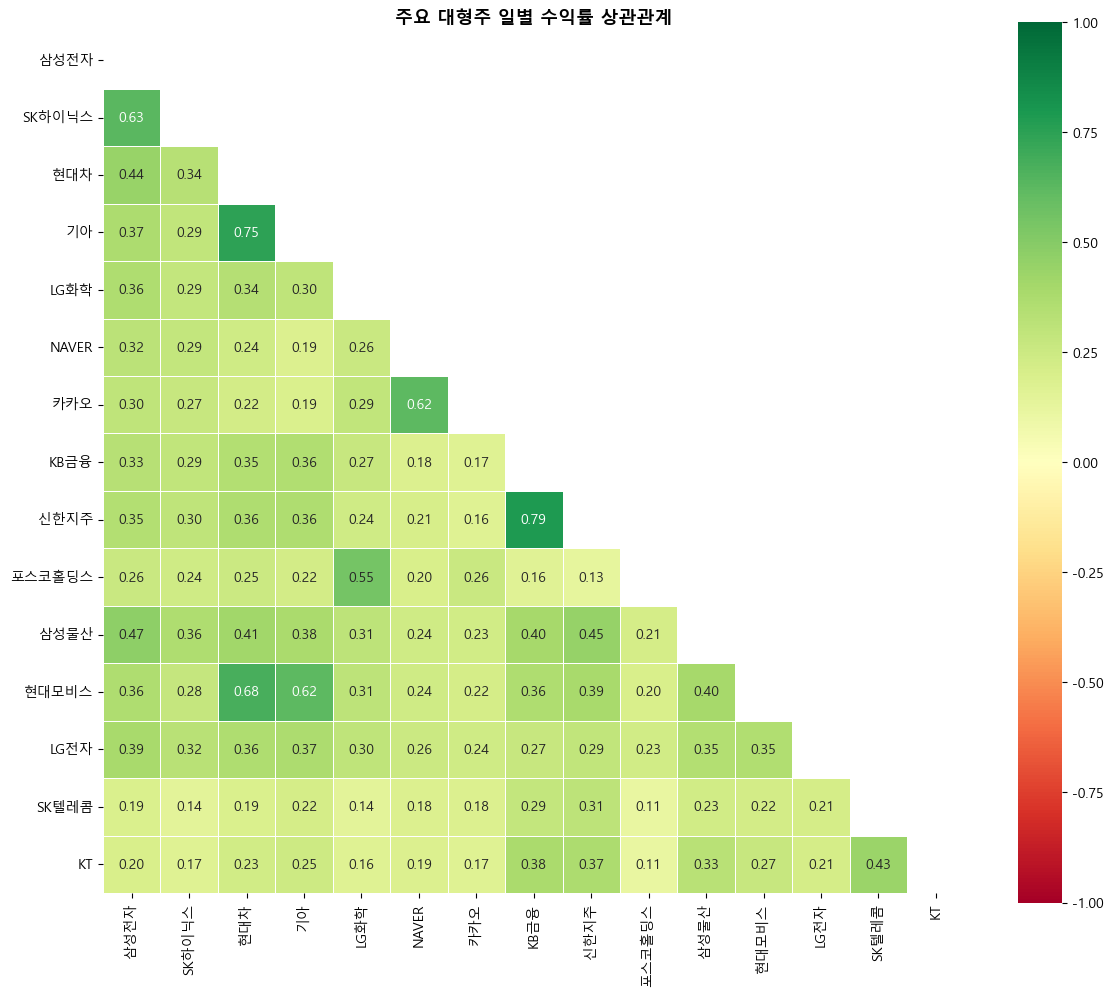


분석 완료! 다음: 03_technical_analysis.ipynb


In [7]:
# ─────────────────────────────────────────
# 6단계: 주요 대형주 상관관계 히트맵
# ─────────────────────────────────────────
top_stocks = {
    '005930': '삼성전자', '000660': 'SK하이닉스', '005380': '현대차',
    '000270': '기아', '051910': 'LG화학', '035420': 'NAVER',
    '035720': '카카오', '105560': 'KB금융', '055550': '신한지주',
    '003670': '포스코홀딩스', '028260': '삼성물산', '012330': '현대모비스',
    '066570': 'LG전자', '017670': 'SK텔레콤', '030200': 'KT',
}

available = {k: v for k, v in top_stocks.items() if k in close_df.columns}
top_close = close_df[list(available.keys())].rename(columns=available)
corr_matrix = top_close.pct_change().dropna().corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('주요 대형주 일별 수익률 상관관계', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n분석 완료! 다음: 03_technical_analysis.ipynb')